### Matthew Riddell 
### D00245674
### MSc in Data Analytics
### Dissertation
### Linear Regressions Notebook

Linear Regressions

In this file I conduct feature selection, assumption checking and modelling to awnser each of the main research questions

For each question I create three Linear Regression models:

#### Research Question 1:

Can socio-economic indicators explain raw signature counts?

Linear Regressions Models:

- 1A
- 1B
- 1C

#### Research Question 2:

Can socio-economic indicators explain participation rates?

Linear Regressions Models:

- 2A
- 2B
- 2C

#### Research Question 3:

Can socio-economic indicators explain participation rates when the analysis is reduced to only successful Petitions?

Linear Regressions Models:

- 3A
- 3B
- 3C

Each model performance is evaluated using OLS regression results

Specifically R Squared 

And RMSE, MAE and Residual Plots

Finally Each model is exported using Joblib


### Link to each Dataset:

### ECI Petitions:
#### 2024

- ECI 01: https://citizens-initiative.europa.eu/initiatives/details/2024/000001_en Ban on conversion practices in the European Union
- ECI 02: https://citizens-initiative.europa.eu/initiatives/details/2024/000002_en European Citizens' Initiative in Defence of Agriculture and Rural Economy in Europe
- ECI 03: https://citizens-initiative.europa.eu/initiatives/details/2024/000004_en My Voice, My Choice: For Safe And Accessible Abortion
- ECI 04: https://citizens-initiative.europa.eu/initiatives/details/2024/000006_en Air-Quotas
- ECI 05: https://citizens-initiative.europa.eu/initiatives/details/2024/000007_en Stop Destroying Videogames
- ECI 06: https://citizens-initiative.europa.eu/initiatives/details/2024/000008_en Stop Cruelty Stop Slaughter
- ECI 07: https://citizens-initiative.europa.eu/initiatives/details/2024/000009_en STOP FAKE FOOD: ORIGIN ON LABEL
- ECI 08: https://citizens-initiative.europa.eu/initiatives/details/2024/000010_en ECI for a Water-Smart and Resilient Europe
- ECI 09: https://citizens-initiative.europa.eu/initiatives/details/2024/000011_en PsychedeliCare

#### 2023

- ECI 10: https://citizens-initiative.europa.eu/initiatives/details/2023/000001_en Stop torture and inhuman treatment at Europe’s borders
- ECI 11: https://citizens-initiative.europa.eu/initiatives/details/2023/000002_en Ensuring a dignified reception of migrants in Europe
- ECI 12: https://citizens-initiative.europa.eu/initiatives/details/2023/000003_en End The Horse Slaughter Age
- ECI 13: https://citizens-initiative.europa.eu/initiatives/details/2023/000004_en Connecting all European capitals and people through a high-speed train network
- ECI 14: https://citizens-initiative.europa.eu/initiatives/details/2023/000005_en Effective implementation of the concept of judicial precedent in EU countries
- ECI 15: https://citizens-initiative.europa.eu/initiatives/details/2023/000006_en Taxing great wealth to finance the ecological and social transition
- ECI 16: https://citizens-initiative.europa.eu/initiatives/details/2023/000007_en Preservation and development of Ukrainian culture, education, language, and traditions in EU states
- ECI 17: https://citizens-initiative.europa.eu/initiatives/details/2023/000008_en EU Live Bus Stop Info
- ECI 18: https://citizens-initiative.europa.eu/initiatives/details/2023/000009_en Trust and Freedom
- ECI 19: https://citizens-initiative.europa.eu/initiatives/details/2023/000011_en Creation of a European Environment Authority

#### 2022

- ECI 20: https://citizens-initiative.europa.eu/initiatives/details/2022/000001_en Win It On The Pitch 
- ECI 21: https://citizens-initiative.europa.eu/initiatives/details/2022/000002_en Fur Free Europe
- ECI 22: https://citizens-initiative.europa.eu/initiatives/details/2022/000003_en End The Slaughter Age
- ECI 23: https://citizens-initiative.europa.eu/initiatives/details/2022/000004_en Good Clothes, Fair Pay
- ECI 24: https://citizens-initiative.europa.eu/initiatives/details/2022/000007_en Protect the EU’s Rural Heritage, Food Security and Supply
- ECI 25: https://citizens-initiative.europa.eu/initiatives/details/2022/000008_en Focus on Specific Learning Disabilities on EU Level
- ECI 26: https://citizens-initiative.europa.eu/initiatives/details/2022/000009_en European Citizens’ Initiative for VEGAN MEAL
- ECI 27: https://citizens-initiative.europa.eu/initiatives/details/2022/000010_en European Day of "Whatever it Takes" 

### Worldstat Kaggle Dataset
https://www.kaggle.com/datasets/nelgiriyewithana/countries-of-the-world-2023

### 2023 Global Development and Prosperity Index 
https://www.kaggle.com/datasets/tarktunataalt/2023-global-country-development-and-prosperity-index

### Media Literacy Index Dataset 2023
https://osis.bg/wp-content/uploads/2023/06/MLI-report-in-English-22.06.pdf

https://osis.bg/?p=4450&lang=en

### Mahara Portfolio:
https://mahara.dkit.ie/view/view.php?t=f816cb6da6dd833aaa2f

### Github Repository:
https://github.com/Matthew-Riddell/MSc-Dissertation

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

import scipy
from scipy import stats
import seaborn as sns

import os
import joblib

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Model Path 

Model path for exporting

In [2]:
model_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models"

### Output Path

In [3]:
output_path = r"C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/outputs"

### Load Dataset

In [4]:
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/data/Prepared Datasets/"
file_name = "master_dataset.csv"
successful_file_name = "successful_master_dataset.csv"
complete_file_name = file_path + file_name
complete_successful_file_name = file_path + successful_file_name

In [5]:
master = pd.read_csv(complete_file_name)

In [6]:
successful_master = pd.read_csv(complete_successful_file_name)

In [7]:
master.head()

,Petition_ID,Petition_Name,Country,Genre,Year,Total_Signatures,Successful,Signatures,Signatures_Per_Capita,Population,Population_Density,GDP_Per_Capita,Unemployment,Tertiary_Enrollment,Life_Expectancy,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
0,eci_table_01,Ban Conversion Practices,Austria,Human Rights,2024,1128063,True,10724,0.001208,8877067.0,109,50277.275087,4.67,85.1,81.6,59,81.19,67.94,85.99,81.93
1,eci_table_01,Ban Conversion Practices,Belgium,Human Rights,2024,1128063,True,47459,0.004133,11484055.0,383,46116.699234,5.59,79.7,81.6,61,80.31,64.55,87.70,84.79
2,eci_table_01,Ban Conversion Practices,Bulgaria,Human Rights,2024,1128063,True,2386,0.000342,6975761.0,64,12328.404026,4.34,71.0,74.9,31,53.12,54.62,68.31,72.79
3,eci_table_01,Ban Conversion Practices,Croatia,Human Rights,2024,1128063,True,8574,0.002108,4067500.0,73,14853.239837,6.93,67.9,78.1,45,56.15,52.19,75.16,73.54
4,eci_table_01,Ban Conversion Practices,Cyprus,Human Rights,2024,1128063,True,696,0.000581,1198575.0,131,20494.877613,7.27,75.9,80.8,39,65.69,56.86,78.31,79.14


## Linear Regressions 1: Raw Signatures

Can socio-economic indicators explain raw signature counts?


#### Hypotheses:

H0

Socio-economic indicators do not explain a significant proportion of the variation in raw signature counts

H1

Socio-economic indicators indicators explain a limited portion of the variation in raw signature counts

## Model 1A

Population + GDP Per Capita vs Signatures

In [8]:
X = master[["Population", "GDP_Per_Capita"]]

y = master["Signatures"]

### Checking Correlations

In [9]:
X.corr(method="spearman")

,Population,GDP_Per_Capita
Population,1.000000,0.044567
GDP_Per_Capita,0.044567,1.000000


weakly correlated meaning there is little to no multicolinearity

### VIF test on variables

VIF to check variables for multicolinearity

In [10]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

         Variable       VIF
0           const  4.034801
1      Population  1.000004
2  GDP_Per_Capita  1.000004


very low VIF values = uncorrelated

### Fitting the Model

In [11]:
X = sm.add_constant(X)

model_1A = sm.OLS(y, X).fit()

print(model_1A.summary())

                            OLS Regression Results                            
Dep. Variable:             Signatures   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     40.29
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           2.55e-17
Time:                        17:37:48   Log-Likelihood:                -8895.0
No. Observations:                 729   AIC:                         1.780e+04
Df Residuals:                     726   BIC:                         1.781e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -3808.0182   3591.857     -1.

### Linear Regression Model 1A - Evaluation

In [12]:
print("R Squared:", model_1A.rsquared)
print("Adjusted R Squared:", model_1A.rsquared_adj)
print("F-statistic:", model_1A.fvalue)
print("Model p-value:", model_1A.f_pvalue)

R Squared: 0.09990934679949715
Adjusted R Squared: 0.09742975822318733
F-statistic: 40.29271136108406
Model p-value: 2.546299206164381e-17


### Predictions

In [13]:
predictions_1A = model_1A.predict(X)

### RMSE

In [14]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_1A)
)

print(rmse)

48181.059394702716


### MAE

In [15]:
mae = mean_absolute_error(
    y,
    predictions_1A
)

print(mae)

16630.70023552485


### Residual plots

In [16]:
residuals_1A = y - predictions_1A

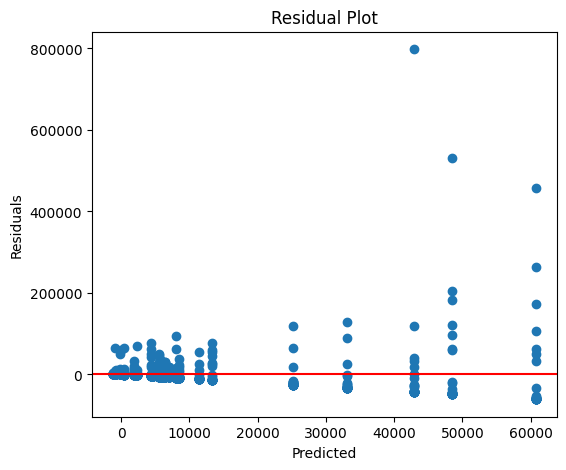

In [17]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_1A, residuals_1A)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

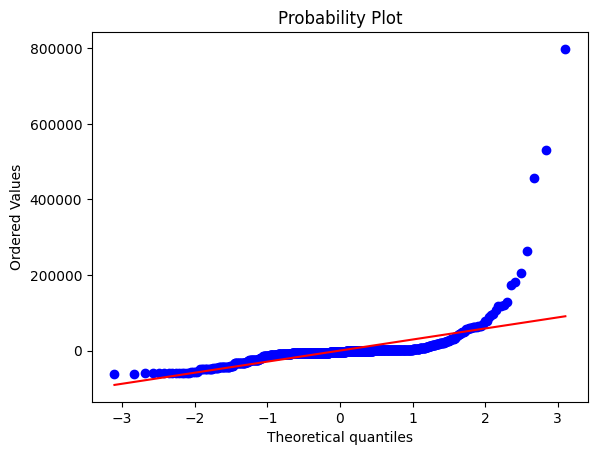

In [18]:
stats.probplot(residuals_1A, dist="norm", plot=plt)

plt.show()

This QQ plot looks reasonable but it goes way off the line at the end tail

### Interpretations

P Value of Population < 0.05

P value of GDP per Capita > 0.05 

- R Squared: 0.09990934679949715

- Adjusted R Squared: 0.09742975822318733

- F-statistic: 40.29271136108406

- Model p-value: 2.546299206164381e-17

- RMSE: 48181.059394702716

- MAE: 16630.70023552485

This model explains roughly 10% of variance in Signatures

The model is high;y significant as the p values < 0.05

THe model predictions differ by roughly 48181 signatures 

The model deviates from target values by about 16630 signatures

This model shows that GDP per Capita and Population explain 10% of the variance in raw signatures

And due to the p value of the model < 0.05 it rejects H0 of Research Question 1




### Export

In [19]:
joblib.dump(
    model_1A,
    rf"{model_path}/regressions/regression_model_1a.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_1a.pkl']

## Model 1B

Population + Population Density + Tertiary Enrollment + Life Expectancy vs Signatures

In [20]:
X = master[
    [
        "Population",
        "Population_Density",
        "Tertiary_Enrollment",
        "Life_Expectancy"
    ]
]

y = master["Signatures"]

### Checking Correlations

In [21]:
X.corr(method="spearman")

,Population,Population_Density,Tertiary_Enrollment,Life_Expectancy
Population,1.000000,0.222833,0.036020,0.240721
Population_Density,0.222833,1.000000,-0.298535,0.295708
Tertiary_Enrollment,0.036020,-0.298535,1.000000,0.113945
Life_Expectancy,0.240721,0.295708,0.113945,1.000000


Low to moderate correlations between variables

### VIF test on variables

VIF to check variables for multicolinearity

In [22]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

              Variable          VIF
0                const  1049.647999
1           Population     1.111231
2   Population_Density     1.198212
3  Tertiary_Enrollment     1.110744
4      Life_Expectancy     1.296997


Low VIF values = little to no multicolinearity

### Fitting the Model

In [23]:
X = sm.add_constant(X)

model_1B = sm.OLS(y, X).fit()

print(model_1B.summary())

                            OLS Regression Results                            
Dep. Variable:             Signatures   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     19.97
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           1.30e-15
Time:                        17:37:49   Log-Likelihood:                -8895.2
No. Observations:                 729   AIC:                         1.780e+04
Df Residuals:                     724   BIC:                         1.782e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -4.785e+04    

### Linear Regression Model 1B - Evaluation

In [24]:
print("R Squared:", model_1B.rsquared)
print("Adjusted R Squared:", model_1B.rsquared_adj)
print("F-statistic:", model_1B.fvalue)
print("Model p-value:", model_1B.f_pvalue)

R Squared: 0.09937624969017278
Adjusted R Squared: 0.09440042786525649
F-statistic: 19.971826401128602
Model p-value: 1.2960089454592907e-15


### Predictions

In [25]:
predictions_1B = model_1B.predict(X)

### RMSE

In [26]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_1B)
)

print(rmse)

48195.32539189874


### MAE

In [27]:
mae = mean_absolute_error(
    y,
    predictions_1B
)

print(mae)

16598.140993771223


### Residual plots

In [28]:
residuals_1B = y - predictions_1B

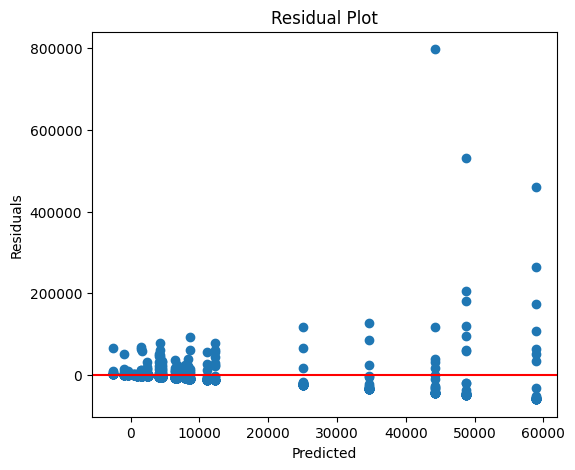

In [29]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_1B, residuals_1B)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

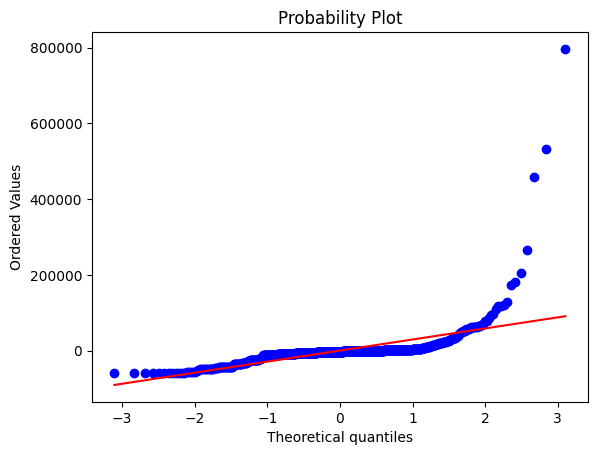

In [30]:
stats.probplot(residuals_1B, dist="norm", plot=plt)

plt.show()

This QQ Plot somewhat fits the line but the tail at the end goes way off

### Interpretations

P Value of Population < 0.05

P Value of Population_Density > 0.05

P Value of Tertiary_Enrollment > 0.05

P Value of Life_Expectancy > 0.05

- R Squared: 0.09937624969017278

- Adjusted R Squared: 0.09440042786525649

- F-statistic: 19.971826401128602

- Model p-value: 1.2960089454592907e-15

- RMSE: 48195.32539189874

- MAE: 16598.140993771223

This model explains roughly 10% of variance in Signatures

The model is highly significant as the p value is < 0.05

THe model predictions differ by roughly 48195 signatures 

The model deviates from target values by about 16598 signatures

This model shows that Popluation, Population Density, Tertiary Enrollment and Life Expectancy explain roughly 10% of the variance in raw signatures

And due to the p value of the model < 0.05 it rejects H0 of Research Question 1




### Export

In [31]:
joblib.dump(
    model_1B,
    rf"{model_path}/regressions/regression_model_1b.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_1b.pkl']

## Model 1C

Population + Media Literacy Index + Governance + Social Capital + Personal Freedom + Education vs Signatures

In [32]:
X = master[
    [
        "Population",
        "Media_Literacy_Index",
        "Governance",
        "Social_Capital",
        "Personal_Freedom",
        "Education"
    ]
]

y = master["Signatures"]

### Checking Correlations

In [33]:
X.corr(method="spearman")

,Population,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
Population,1.000000,0.090131,-0.026252,0.064713,-0.069302,0.066860
Media_Literacy_Index,0.090131,1.000000,0.860679,0.734189,0.871200,0.860046
Governance,-0.026252,0.860679,1.000000,0.763736,0.961380,0.830408
Social_Capital,0.064713,0.734189,0.763736,1.000000,0.775149,0.622500
Personal_Freedom,-0.069302,0.871200,0.961380,0.775149,1.000000,0.777405
Education,0.066860,0.860046,0.830408,0.622500,0.777405,1.000000


Media Literacy Index, Governance, Social Capital, Personal Freedom and Education are all strongly correlated with one another

### VIF test on variables

VIF to check variables for multicolinearity

In [34]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

               Variable          VIF
0                 const  1452.457929
1            Population     1.093875
2  Media_Literacy_Index     5.288223
3            Governance    16.322263
4        Social_Capital     2.453977
5      Personal_Freedom    12.765911
6             Education     4.631295


High VIF values with Personal Freedom, Education, Media Literacy, Governance, Social Capital

There is strong Multicolinearity between each variable

### Fitting the Model

In [35]:
X = sm.add_constant(X)

model_1C = sm.OLS(y, X).fit()

print(model_1C.summary())

                            OLS Regression Results                            
Dep. Variable:             Signatures   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     13.57
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           1.26e-14
Time:                        17:37:50   Log-Likelihood:                -8894.4
No. Observations:                 729   AIC:                         1.780e+04
Df Residuals:                     722   BIC:                         1.784e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -4.067e+04 

### Linear Regression Model 1C - Evaluation

In [36]:
print("R Squared:", model_1C.rsquared)
print("Adjusted R Squared:", model_1C.rsquared_adj)
print("F-statistic:", model_1C.fvalue)
print("Model p-value:", model_1C.f_pvalue)

R Squared: 0.10132061322787378
Adjusted R Squared: 0.09385236347630499
F-statistic: 13.566848538586772
Model p-value: 1.2635107383049087e-14


### Predictions

In [37]:
predictions_1C = model_1C.predict(X)

### RMSE

In [38]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_1C)
)

print(rmse)

48143.27265322001


### MAE

In [39]:
mae = mean_absolute_error(
    y,
    predictions_1C
)

print(mae)

16649.580577972207


### Residual plots

In [40]:
residuals_1C = y - predictions_1C

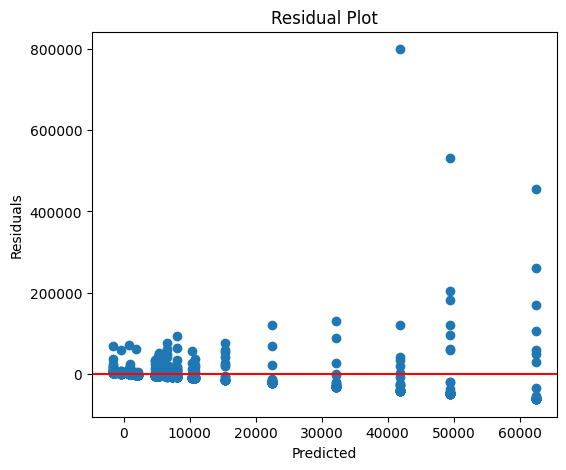

In [41]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_1C, residuals_1C)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

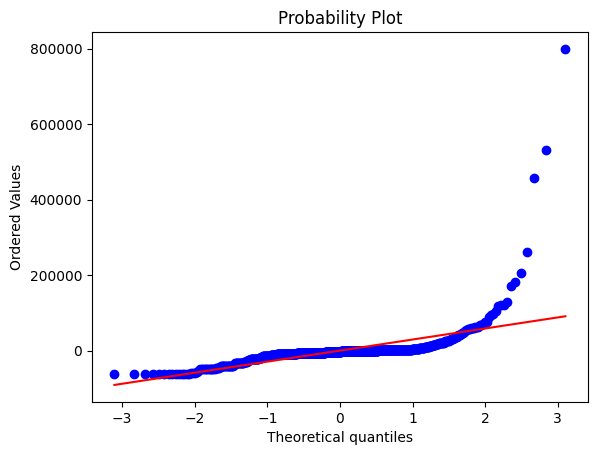

In [42]:
stats.probplot(residuals_1C, dist="norm", plot=plt)

plt.show()

This QQ Plot somewhat fits the line but goes way off at the end tail

### Interpretations

P Value of Population < 0.05

P Value of Media Literacy Index > 0.05

P Value of Governance > 0.05

P Value of Social_Capital > 0.05

P Value of Personal Freedom > 0.05

P Value of Education > 0.05

- R Squared: 0.10132061322787378

- Adjusted R Squared: 0.09385236347630499

- F-statistic: 13.566848538586772

- Model p-value: 1.2635107383049087e-14

- RMSE: 48143.27265322001

- MAE: 16649.580577972207

This model explains roughly 10% of variance in Signatures

The model is highly significant as the p value is < 0.05

THe model predictions differ by roughly 48143 signatures 

The model deviates from target values by about 16649 signatures

This model shows that Population, Media Literacy Index, Governance, Social Capital, Personal Freedom and Education explain roughly 10% of the variance in raw signatures

And due to the p value of the model < 0.05 it rejects H0 of Research Question 1




### Export

In [43]:
joblib.dump(
    model_1C,
    rf"{model_path}/regressions/regression_model_1c.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_1c.pkl']

## Linear Regressions 2: Signatures Per Capita

Can socio-economic indicators explain participation rates?

#### Hypotheses: 

H0

Socio-economic indicators have no significant relationship with participation rates when participation is normalised by population

H1

Socio-economic indicators have a limited explanatory power when participation is normalised by population

## Model 2A

GDP Per Capita + Unemployment vs Signatures Per Capita

In [44]:
X = master[
    [
        "GDP_Per_Capita",
        "Unemployment"
    ]
]

y = master["Signatures_Per_Capita"]

### Checking Correlations

In [45]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment
GDP_Per_Capita,1.000000,0.007022
Unemployment,0.007022,1.000000


weakly correlated meaning there is little to no multicolinearity

### VIF test on variables

VIF to check variables for multicolinearity

In [46]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

         Variable       VIF
0           const  7.631218
1  GDP_Per_Capita  1.010885
2    Unemployment  1.010885


very low VIF values meaning little to no Multicolinearity

### Fitting the Model

In [47]:
X = sm.add_constant(X)

model_2A = sm.OLS(y, X).fit()

print(model_2A.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.005
Model:                               OLS   Adj. R-squared:                  0.002
Method:                    Least Squares   F-statistic:                     1.656
Date:                   Mon, 10 Aug 2026   Prob (F-statistic):              0.192
Time:                           17:37:50   Log-Likelihood:                 3329.9
No. Observations:                    729   AIC:                            -6654.
Df Residuals:                        726   BIC:                            -6640.
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const         

### Linear Regression Model 2A - Evaluation

In [48]:
print("R Squared:", model_2A.rsquared)
print("Adjusted R Squared:", model_2A.rsquared_adj)
print("F-statistic:", model_2A.fvalue)
print("Model p-value:", model_2A.f_pvalue)

R Squared: 0.004540913652041678
Adjusted R Squared: 0.001798602119402748
F-statistic: 1.6558708221132903
Model p-value: 0.1916459661657725


### Predictions

In [49]:
predictions_2A = model_2A.predict(X)

### RMSE

In [50]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_2A)
)

print(rmse)

0.0025119420544639564


### MAE

In [51]:
mae = mean_absolute_error(
    y,
    predictions_2A
)

print(mae)

0.001186789429744381


### Residual plots

In [52]:
residuals_2A = y - predictions_2A

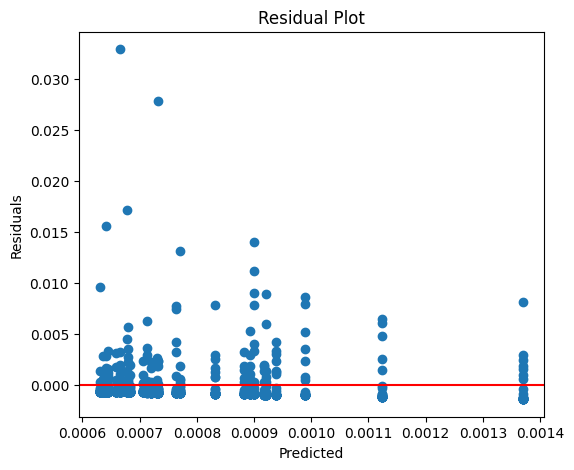

In [53]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_2A, residuals_2A)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

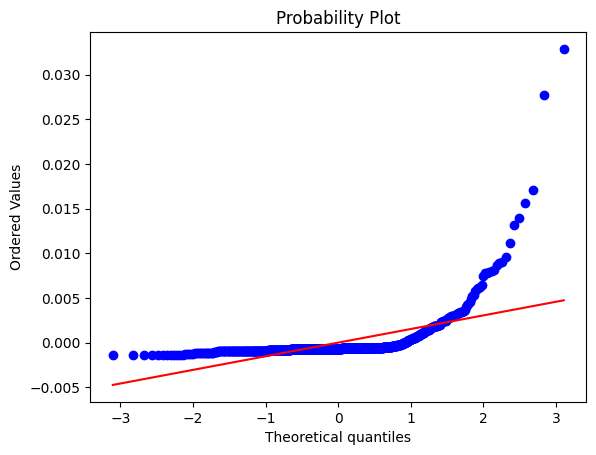

In [54]:
stats.probplot(residuals_2A, dist="norm", plot=plt)

plt.show()

This QQ Plot doesnt fit the line too well

### Interpretations

P value of GDP per Capita > 0.05 

P value of Unemployment > 0.05 

- R Squared: 0.004540913652041678

- Adjusted R Squared: 0.001798602119402748

- F-statistic: 1.6558708221132903

- Model p-value: 0.1916459661657725

- RMSE: 0.0025119420544639564

- MAE: 0.001186789429744381

This model explains roughly 0.45% of variance in Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

GDP per Capita and Unemployment poorly explain variance in signatures per capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 2




### Export

In [55]:
joblib.dump(
    model_2A,
    rf"{model_path}/regressions/regression_model_2a.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_2a.pkl']

## Model 2B

GDP Per Capita + Unemployment + Tertiary Enrollment + Life Expectancy + Population Density vs Signatures Per Capita

In [56]:
X = master[
    [
        "GDP_Per_Capita",
        "Unemployment",
        "Tertiary_Enrollment",
        "Life_Expectancy",
        "Population_Density"
    ]
]

y = master["Signatures_Per_Capita"]

### Checking Correlations

In [57]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment,Tertiary_Enrollment,Life_Expectancy,Population_Density
GDP_Per_Capita,1.000000,0.007022,0.217338,0.773790,0.300366
Unemployment,0.007022,1.000000,0.282705,0.313627,-0.361166
Tertiary_Enrollment,0.217338,0.282705,1.000000,0.113945,-0.298535
Life_Expectancy,0.773790,0.313627,0.113945,1.000000,0.295708
Population_Density,0.300366,-0.361166,-0.298535,0.295708,1.000000


GDP Per Capita and Life Expectancy share the highest correlations with one another and among other variables

### VIF test on variables

VIF to check variables for multicolinearity

In [58]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

              Variable          VIF
0                const  1969.790541
1       GDP_Per_Capita     2.123164
2         Unemployment     1.862834
3  Tertiary_Enrollment     1.608670
4      Life_Expectancy     2.666884
5   Population_Density     1.385294


GDP per Capita and Life Expectancy have high VIF values Suggesting Multicolinearity

### Fitting the Model

In [59]:
X = sm.add_constant(X)

model_2B = sm.OLS(y, X).fit()

print(model_2B.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.007
Model:                               OLS   Adj. R-squared:                 -0.000
Method:                    Least Squares   F-statistic:                    0.9846
Date:                   Mon, 10 Aug 2026   Prob (F-statistic):              0.426
Time:                           17:37:51   Log-Likelihood:                 3330.7
No. Observations:                    729   AIC:                            -6649.
Df Residuals:                        723   BIC:                            -6622.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

### Linear Regression Model 2B - Evaluation

In [60]:
print("R Squared:", model_2B.rsquared)
print("Adjusted R Squared:", model_2B.rsquared_adj)
print("F-statistic:", model_2B.fvalue)
print("Model p-value:", model_2B.f_pvalue)

R Squared: 0.006762903327590886
Adjusted R Squared: -0.00010595626212150933
F-statistic: 0.9845744026737415
Model p-value: 0.4261737620421674


### Predictions

In [61]:
predictions_2B = model_2B.predict(X)

### RMSE

In [62]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_2B)
)

print(rmse)

0.0025091370032440706


### MAE

In [63]:
mae = mean_absolute_error(
    y,
    predictions_2B
)

print(mae)

0.0011877750463887542


### Residual Plots

In [64]:
residuals_2B = y - predictions_2B

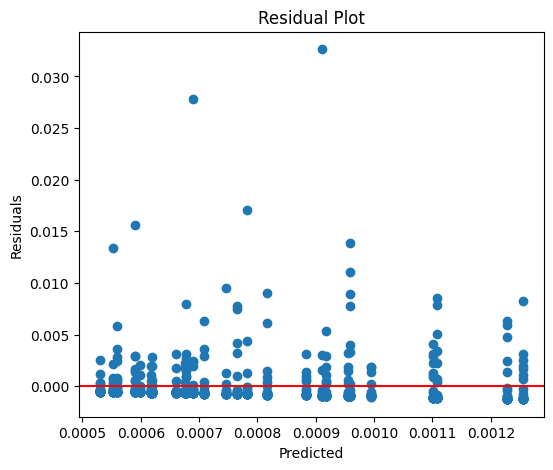

In [65]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_2B, residuals_2B)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

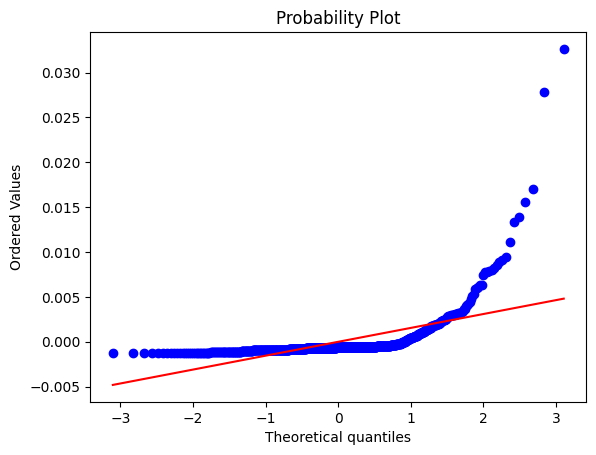

In [66]:
stats.probplot(residuals_2B, dist="norm", plot=plt)

plt.show()

This QQ plot doesnt fit the line too well

### Interpretations

P Value of GDP_Per_Capita > 0.05

P Value of Unemployment > 0.05

P Value of Tertiary_Enrollment > 0.05

P Value of Life_Expectancy > 0.05

P Value of Population_Density > 0.05

- R Squared: 0.006762903327590886

- Adjusted R Squared: -0.00010595626212150933

- F-statistic: 0.9845744026737415

- Model p-value: 0.4261737620421674

- RMSE: 0.0025091370032440706

- MAE: 0.0011877750463887542

This model explains roughly 0.67% of variance in Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

GDP per Capita, Unemployment Tertiary Enrollment, LIfe Expectancy and Population Density poorly explain variance in Signatures Per Capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 2




### Export

In [67]:
joblib.dump(
    model_2B,
    rf"{model_path}/regressions/regression_model_2b.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_2b.pkl']

## Model 2C

Media Literacy Index + Governance + Social Capital + Personal Freedom + Education vs Signatures Per Capita

In [68]:
X = master[
    [
        "Media_Literacy_Index",
        "Governance",
        "Social_Capital",
        "Personal_Freedom",
        "Education"
    ]
]

y = master["Signatures_Per_Capita"]

### Checking Correlations

In [69]:
X.corr(method="spearman")

,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
Media_Literacy_Index,1.000000,0.860679,0.734189,0.871200,0.860046
Governance,0.860679,1.000000,0.763736,0.961380,0.830408
Social_Capital,0.734189,0.763736,1.000000,0.775149,0.622500
Personal_Freedom,0.871200,0.961380,0.775149,1.000000,0.777405
Education,0.860046,0.830408,0.622500,0.777405,1.000000


Media Literacy Index, Governance, Social Capital, Personal Freedom and Education are all strongly correlated with one another

### VIF test on variables

VIF to check variables for multicolinearity

In [70]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

               Variable          VIF
0                 const  1419.727030
1  Media_Literacy_Index     5.287755
2            Governance    15.308980
3        Social_Capital     2.452434
4      Personal_Freedom    11.777940
5             Education     4.625809


High VIF values with Personal Freedom, Education, Media Literacy, Governance, Social Capital

There is strong Multicolinearity between each variable

### Fitting the Model

In [71]:
X = sm.add_constant(X)

model_2C = sm.OLS(y, X).fit()

print(model_2C.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.008
Model:                               OLS   Adj. R-squared:                  0.001
Method:                    Least Squares   F-statistic:                     1.157
Date:                   Mon, 10 Aug 2026   Prob (F-statistic):              0.329
Time:                           17:37:52   Log-Likelihood:                 3331.1
No. Observations:                    729   AIC:                            -6650.
Df Residuals:                        723   BIC:                            -6623.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

### Linear Regression Model 2C - Evaluation

In [72]:
print("R Squared:", model_2C.rsquared)
print("Adjusted R Squared:", model_2C.rsquared_adj)
print("F-statistic:", model_2C.fvalue)
print("Model p-value:", model_2C.f_pvalue)

R Squared: 0.0079352755410812
Adjusted R Squared: 0.0010745236430250715
F-statistic: 1.1566189331710908
Model p-value: 0.3290380642093612


### Predictions

In [73]:
predictions_2C = model_2C.predict(X)

### RMSE

In [74]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_2C)
)

print(rmse)

0.0025076557300060536


### MAE

In [75]:
mae = mean_absolute_error(
    y,
    predictions_2C
)

print(mae)

0.0011881254635765293


### Residual Plots

In [76]:
residuals_2C = y - predictions_2C

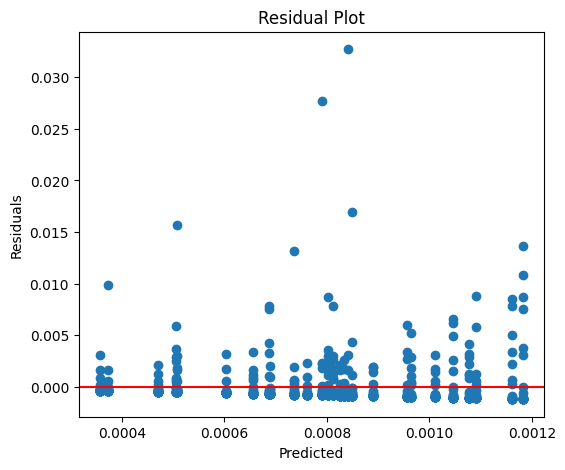

In [77]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_2C, residuals_2C)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

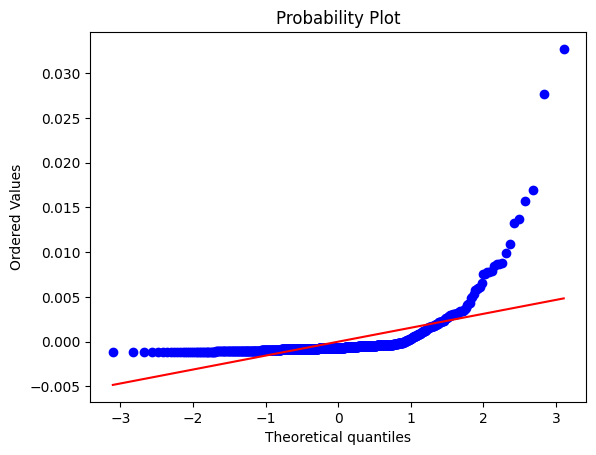

In [78]:
stats.probplot(residuals_2C, dist="norm", plot=plt)

plt.show()

This QQ plot doesnt fit the line too well

### Interpretations

P Value of Media Literacy Index > 0.05

P Value of Governance > 0.05

P Value of Social Capital > 0.05

P Value of Personal Freedom > 0.05

P Value of Education > 0.05

- R Squared: 0.0079352755410812

- Adjusted R Squared: 0.0010745236430250715

- F-statistic: 1.1566189331710908

- Model p-value: 0.3290380642093612

- RMSE: 0.0025076557300060536

- MAE: 0.0011881254635765293

This model explains roughly 0.79% of variance in Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

Media Literacy Index, Governance, Social Capital, Personal Freedom and Education poorly explain variance in signatures per capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 2

### Export

In [79]:
joblib.dump(
    model_2C,
    rf"{model_path}/regressions/regression_model_2c.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_2c.pkl']

## Linear Regressions 3: Signatures Per Capita (Successful ECI Petitions only)

Can socio-economic indicators explain participation rates when the analysis is reduced to only successful Petitions?

#### Hypotheses: 

H0

Socio-economic indicators have no significant relationship with participation rates when participation is normalised by population

H1

Socio-economic indicators have a limited explanatory power when participation is normalised by population

## Model 3A

GDP Per Capita + Unemployment vs Signatures Per Capita

In [80]:
X = successful_master[
    [
        "GDP_Per_Capita",
        "Unemployment"
    ]
]

y = successful_master["Signatures_Per_Capita"]

### Checking Correlations

In [81]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment
GDP_Per_Capita,1.000000,0.007022
Unemployment,0.007022,1.000000


low correlation between GDP Per Capita and Unemployment

### VIF test on variables

VIF to check variables for multicolinearity

In [82]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

         Variable       VIF
0           const  7.631218
1  GDP_Per_Capita  1.010885
2    Unemployment  1.010885


very low VIF values meaning little to no Multicolinearity

### Fitting the Model

In [83]:
X = sm.add_constant(X)

model_3A = sm.OLS(y, X).fit()

print(model_3A.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.003
Model:                               OLS   Adj. R-squared:                 -0.016
Method:                    Least Squares   F-statistic:                    0.1490
Date:                   Mon, 10 Aug 2026   Prob (F-statistic):              0.862
Time:                           17:37:53   Log-Likelihood:                 420.12
No. Observations:                    108   AIC:                            -834.2
Df Residuals:                        105   BIC:                            -826.2
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const         

### Linear Regression Model 3A - Evaluation

In [84]:
print("R Squared:", model_3A.rsquared)
print("Adjusted R Squared:", model_3A.rsquared_adj)
print("F-statistic:", model_3A.fvalue)
print("Model p-value:", model_3A.f_pvalue)

R Squared: 0.0028302050507570398
Adjusted R Squared: -0.01616350532922839
F-statistic: 0.14900748690678955
Model p-value: 0.8617445251109912


### Predictions

In [85]:
predictions_3A = model_3A.predict(X)

### RMSE

In [86]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_3A)
)

print(rmse)

0.004947186712620768


### MAE

In [87]:
mae = mean_absolute_error(
    y,
    predictions_3A
)

print(mae)

0.002898052335851381


### Residual Plots

In [88]:
residuals_3A = y - predictions_3A

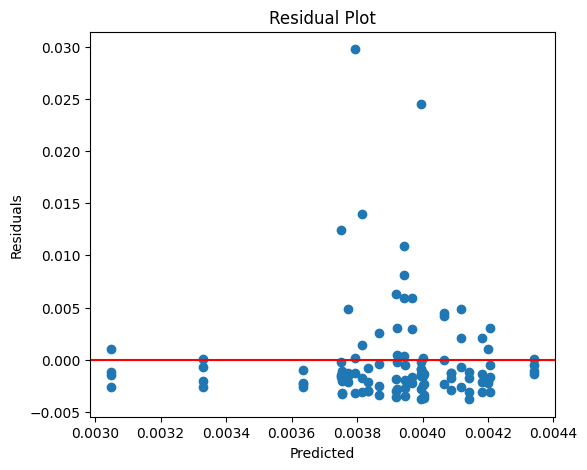

In [89]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_3A, residuals_3A)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

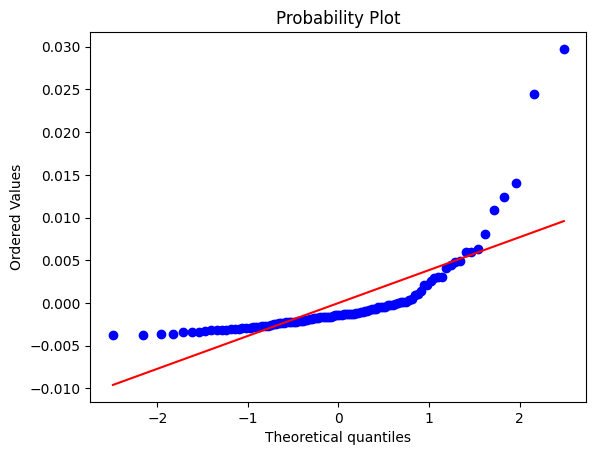

In [90]:
stats.probplot(residuals_3A, dist="norm", plot=plt)

plt.show()

This QQ plot is way off the line

### Interpretations

P value of GDP per Capita > 0.05 

P value of Unemployment > 0.05 

- R Squared: 0.0028302050507570398

- Adjusted R Squared: -0.01616350532922839

- F-statistic: 0.14900748690678955

- Model p-value: 0.8617445251109912

- RMSE: 0.004947186712620768

- MAE: 0.002898052335851381

This model explains roughly 0.28% of variance in Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

GDP per Capita and Unemployment poorly explain variance in signatures per capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 3




### Export

In [91]:
joblib.dump(
    model_3A,
    rf"{model_path}/regressions/regression_model_3a.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_3a.pkl']

## Model 3B

GDP Per Capita + Unemployment + Tertiary Enrollment + Life Expectancy + Population Density vs Signatures Per Capita

In [92]:
X = successful_master[
    [
        "GDP_Per_Capita",
        "Unemployment",
        "Tertiary_Enrollment",
        "Life_Expectancy",
        "Population_Density"
    ]
]

y = successful_master["Signatures_Per_Capita"]

### Checking Correlations

In [93]:
X.corr(method="spearman")

,GDP_Per_Capita,Unemployment,Tertiary_Enrollment,Life_Expectancy,Population_Density
GDP_Per_Capita,1.000000,0.007022,0.217338,0.773790,0.300366
Unemployment,0.007022,1.000000,0.282705,0.313627,-0.361166
Tertiary_Enrollment,0.217338,0.282705,1.000000,0.113945,-0.298535
Life_Expectancy,0.773790,0.313627,0.113945,1.000000,0.295708
Population_Density,0.300366,-0.361166,-0.298535,0.295708,1.000000


GDP Per Capita and Life Expectancy share the highest correlations with one another and among other variables

### VIF test on variables

VIF to check variables for multicolinearity

In [94]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

              Variable          VIF
0                const  1969.790541
1       GDP_Per_Capita     2.123164
2         Unemployment     1.862834
3  Tertiary_Enrollment     1.608670
4      Life_Expectancy     2.666884
5   Population_Density     1.385294


GDP per Capita and Life Expectancy have high VIF values Suggesting Multicolinearity

### Fitting the Model

In [95]:
X = sm.add_constant(X)

model_3B = sm.OLS(y, X).fit()

print(model_3B.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.033
Model:                               OLS   Adj. R-squared:                 -0.015
Method:                    Least Squares   F-statistic:                    0.6940
Date:                   Mon, 10 Aug 2026   Prob (F-statistic):              0.629
Time:                           17:37:54   Log-Likelihood:                 421.77
No. Observations:                    108   AIC:                            -831.5
Df Residuals:                        102   BIC:                            -815.5
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

### Linear Regression Model 3B - Evaluation

In [96]:
print("R Squared:", model_3B.rsquared)
print("Adjusted R Squared:", model_3B.rsquared_adj)
print("F-statistic:", model_3B.fvalue)
print("Model p-value:", model_3B.f_pvalue)

R Squared: 0.03290000337671328
Adjusted R Squared: -0.014506859202859657
F-statistic: 0.6939924219091752
Model p-value: 0.6291448362136607


### Predictions

In [97]:
predictions_3B = model_3B.predict(X)

### RMSE

In [98]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_3B)
)

print(rmse)

0.004872024178202524


### MAE

In [99]:
mae = mean_absolute_error(
    y,
    predictions_3B
)

print(mae)

0.0028616407062963703


### Residual Plots

In [100]:
residuals_3B = y - predictions_3B

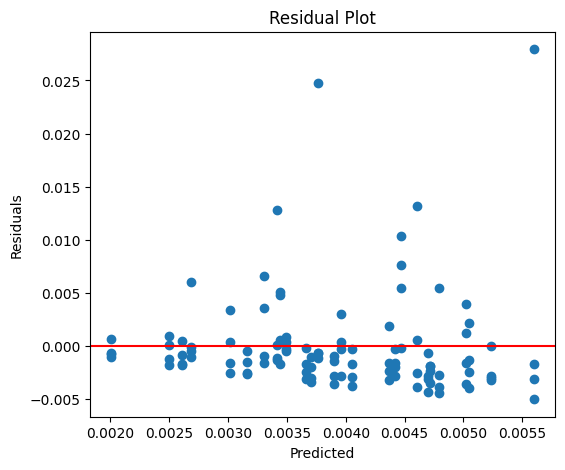

In [101]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_3B, residuals_3B)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

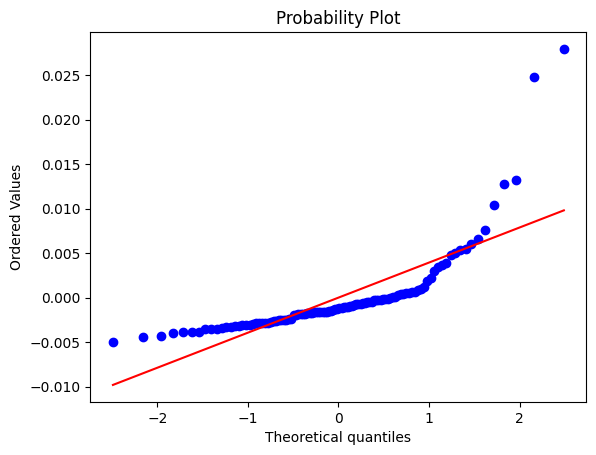

In [102]:
stats.probplot(residuals_3B, dist="norm", plot=plt)

plt.show()

This QQ plot doesnt fit the line too well

### Interpretations

P Value of GDP_Per_Capita > 0.05

P Value of Unemployment > 0.05

P Value of Tertiary_Enrollment > 0.05

P Value of Life_Expectancy > 0.05

P Value of Population_Density > 0.05

- R Squared: 0.03290000337671328

- Adjusted R Squared: -0.014506859202859657

- F-statistic: 0.6939924219091752

- Model p-value: 0.6291448362136607

- RMSE: 0.004872024178202524

- MAE: 0.0028616407062963703

This model explains roughly 3.29% of variance in Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

GDP per Capita, Unemployment, Tertiary Enrollment, Life Expectancy and Population Density poorly explain variance in Signatures Per Capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 3




### Export

In [103]:
joblib.dump(
    model_3B,
    rf"{model_path}/regressions/regression_model_3b.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_3b.pkl']

## Model 3C

Media Literacy Index + Governance + Social Capital + Personal Freedom + Education vs Signatures Per Capita

In [104]:
X = successful_master[
    [
        "Media_Literacy_Index",
        "Governance",
        "Social_Capital",
        "Personal_Freedom",
        "Education"
    ]
]

y = successful_master["Signatures_Per_Capita"]

### Checking Correlations

In [105]:
X.corr(method="spearman")

,Media_Literacy_Index,Governance,Social_Capital,Personal_Freedom,Education
Media_Literacy_Index,1.000000,0.860679,0.734189,0.871200,0.860046
Governance,0.860679,1.000000,0.763736,0.961380,0.830408
Social_Capital,0.734189,0.763736,1.000000,0.775149,0.622500
Personal_Freedom,0.871200,0.961380,0.775149,1.000000,0.777405
Education,0.860046,0.830408,0.622500,0.777405,1.000000


Media Literacy Index, Governance, Social Capital, Personal Freedom and Education are all strongly correlated with one another

### VIF test on variables

VIF to check variables for multicolinearity

In [106]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif)

               Variable          VIF
0                 const  1419.727030
1  Media_Literacy_Index     5.287755
2            Governance    15.308980
3        Social_Capital     2.452434
4      Personal_Freedom    11.777940
5             Education     4.625809


High VIF values with Personal Freedom, Education, Media Literacy, Governance, Social Capital

There is strong Multicolinearity between each variable

### Fitting the Model

In [107]:
X = sm.add_constant(X)

model_3C = sm.OLS(y, X).fit()

print(model_3C.summary())

                              OLS Regression Results                             
Dep. Variable:     Signatures_Per_Capita   R-squared:                       0.043
Model:                               OLS   Adj. R-squared:                 -0.004
Method:                    Least Squares   F-statistic:                    0.9187
Date:                   Mon, 10 Aug 2026   Prob (F-statistic):              0.472
Time:                           17:37:54   Log-Likelihood:                 422.35
No. Observations:                    108   AIC:                            -832.7
Df Residuals:                        102   BIC:                            -816.6
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

### Linear Regression Model 3C - Evaluation

In [108]:
print("R Squared:", model_3C.rsquared)
print("Adjusted R Squared:", model_3C.rsquared_adj)
print("F-statistic:", model_3C.fvalue)
print("Model p-value:", model_3C.f_pvalue)

R Squared: 0.04309154342080623
Adjusted R Squared: -0.003815733862487569
F-statistic: 0.9186536912078118
Model p-value: 0.4721203493276124


### Predictions

In [109]:
predictions_3C = model_3C.predict(X)

### RMSE

In [110]:
rmse = np.sqrt(
    mean_squared_error(y, predictions_3C)
)

print(rmse)

0.004846284886205672


### MAE

In [111]:
mae = mean_absolute_error(
    y,
    predictions_3C
)

print(mae)

0.002891861952111684


### Residual Plots

In [112]:
residuals_3C = y - predictions_3C

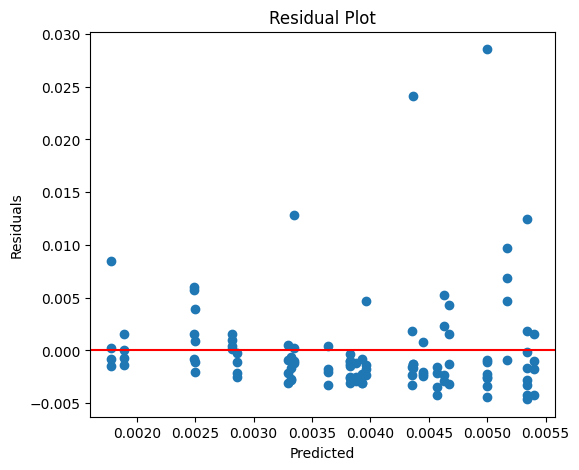

In [113]:
plt.figure(figsize=(6,5))
plt.scatter(predictions_3C, residuals_3C)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

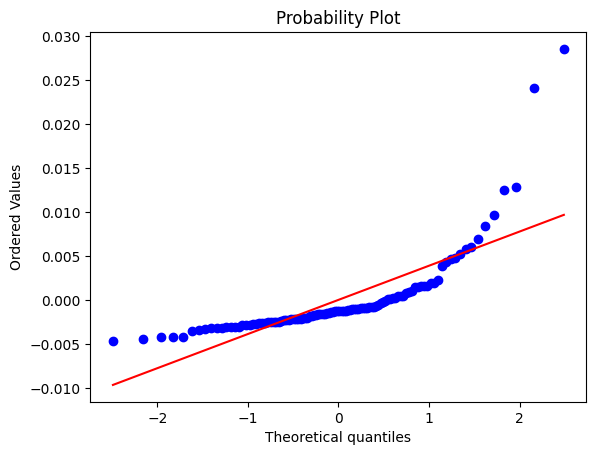

In [114]:
stats.probplot(residuals_3C, dist="norm", plot=plt)

plt.show()

### Interpretations

P Value of Media Literacy Index > 0.05

P Value of Governance > 0.05

P Value of Social Capital > 0.05

P Value of Personal Freedom > 0.05

P Value of Education > 0.05

- R Squared: 0.04309154342080623

- Adjusted R Squared: -0.003815733862487569

- F-statistic: 0.9186536912078118

- Model p-value: 0.4721203493276124

- RMSE: 0.004846284886205672

- MAE: 0.002891861952111684

This model explains roughly 4.30% of variance in Signatures Per Capita

The model performs poorly and is insignificant as the p value is > 0.05

Media Literacy Index, Governance, Social Capital, Personal Freedom and Education poorly explain variance in signatures per capita in this model

And due to the p value of the model > 0.05 it fails to reject H0 of Research Question 3

### Export

In [115]:
joblib.dump(
    model_3C,
    rf"{model_path}/regressions/regression_model_3c.pkl"
)

['C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Dissertation/MSc-Dissertation/models/regressions/regression_model_3c.pkl']

### Linear Regressions Evaluation

The Models for Question 1 proved that the country level variables explain roughly 10% of variance in Raw Signatures

This means that the Null Hypothesis for Question 1 is rejected 

The models for Question 2 fail to prove that country level variables explain a significant amount of variance in Signatures per Capita

Currently failed to reject Null hypothesis

The models for Question 3 fail to prove that country level variables explain a significant amount of variance in Signatures per Capita

Currently failed to reject Null hypothesis

While these models fail to explain significant variance, its worth noting that the R Squared values increased and the P value decresed with each subsequent model

This shows that maybe under certain transformations the variable may explain variance as they may have non linear relationships with Signatures Per Capita that Linear Regressions fail to explain

I will continue to develop more models such as PCA regressions, Log Linear Regressions and Random Forest Regressions 

to try and create a model that explains a significant portion of variance of Signatures Per Capita 

and reject the Null Hypothesis and providing an answer to Research Question 2 and Question 3